**1. Импорт библиотек**

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.arima_process import ArmaProcess
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX
import warnings
warnings.filterwarnings('ignore')

**2. Определение коэффициентов модели**

Уравнение ARMA(4,3):

$$X_t = \phi_1 X_{t-1} + \phi_2 X_{t-2} + \phi_3 X_{t-3} + \phi_4 X_{t-4} + \varepsilon_t + \theta_1 \varepsilon_{t-1} + \theta_2 \varepsilon_{t-2} + \theta_3 \varepsilon_{t-3}$$

Конкретные значения (θ₃ = 0.19 вместо 0.20 — убираем корень MA-полинома ровно на единичной окружности, чтобы выполнялась **обратимость**):

$$X_t = 0{,}6\,X_{t-1} - 0{,}4\,X_{t-2} + 0{,}2\,X_{t-3} - 0{,}1\,X_{t-4} + \varepsilon_t + 0{,}5\,\varepsilon_{t-1} - 0{,}3\,\varepsilon_{t-2} + 0{,}19\,\varepsilon_{t-3}$$

Выберем коэффициенты так, чтобы процесс был стационарным и обратимым (проверка — по корням характеристических полиномов ниже).

In [19]:
# Истинные коэффициенты (AR и MA)
phi = np.array([0.6, -0.4, 0.2, -0.1])   # φ1, φ2, φ3, φ4
theta = np.array([0.5, -0.3, 0.19])      # θ1, θ2, θ3 (θ3 слегка уменьшен для обратимости MA)

print("Коэффициенты AR (φ):", phi)
print("Коэффициенты MA (θ):", theta)

Коэффициенты AR (φ): [ 0.6 -0.4  0.2 -0.1]
Коэффициенты MA (θ): [ 0.5  -0.3   0.19]


**2.1 Проверка стационарности (корни AR-полинома)**

Характеристический полином AR: $1 - \phi_1 z - \phi_2 z^2 - \phi_3 z^3 - \phi_4 z^4 = 0$

Процесс стационарен, если все корни по модулю **строго больше** 1 (лежат **вне** единичного круга).

**Важно:** `numpy.roots` принимает коэффициенты **от старшей степени к младшей** (как в `np.poly`), а не «от свободного члена».

In [20]:
# Коэффициенты для np.roots: -φ4*z^4 - φ3*z^3 - φ2*z^2 - φ1*z + 1 = 0 (старшая степень первая)
ar_poly_desc = np.r_[-phi[::-1], 1]
ar_roots = np.roots(ar_poly_desc)
print("\nКорни AR-полинома:")
for i, r in enumerate(ar_roots):
    print(f"  Корень {i+1}: {r:.4f}  |r| = {np.abs(r):.4f}")
if np.all(np.abs(ar_roots) > 1):
    print("Все корни вне единичного круга → процесс стационарен.")
else:
    print("Некоторые корни внутри или на границе единичного круга → процесс нестационарен. Измените коэффициенты.")


Корни AR-полинома:
  Корень 1: 1.4120+1.1222j  |r| = 1.8037
  Корень 2: 1.4120-1.1222j  |r| = 1.8037
  Корень 3: -0.4120+1.7042j  |r| = 1.7532
  Корень 4: -0.4120-1.7042j  |r| = 1.7532
Все корни вне единичного круга → процесс стационарен.


**2.2 Проверка обратимости (корни MA-полинома)**

Характеристический полином MA: $1 + \theta_1 z + \theta_2 z^2 + \theta_3 z^3 = 0$

Процесс обратим, если все корни по модулю **строго больше** 1.

Для `numpy.roots`: коэффициенты от старшей степени — $[\theta_3,\,\theta_2,\,\theta_1,\,1]$.

In [21]:
ma_poly_desc = np.r_[theta[::-1], 1]   # θ3*z^3 + θ2*z^2 + θ1*z + 1 = 0
ma_roots = np.roots(ma_poly_desc)
print("\nКорни MA-полинома:")
for i, r in enumerate(ma_roots):
    print(f"  Корень {i+1}: {r:.4f}  |r| = {np.abs(r):.4f}")
if np.all(np.abs(ma_roots) > 1):
    print("Все корни вне единичного круга → процесс обратим.")
else:
    print("Некоторые корни внутри или на границе единичного круга → процесс необратим. Измените коэффициенты.")


Корни MA-полинома:
  Корень 1: 1.2925+1.8872j  |r| = 2.2873
  Корень 2: 1.2925-1.8872j  |r| = 2.2873
  Корень 3: -1.0060+0.0000j  |r| = 1.0060
Все корни вне единичного круга → процесс обратим.


**3. Генерация 300 наблюдений**

In [22]:
# Создаём объект ARMA-процесса
ar_params = np.r_[1, -phi]   # AR-параметры: [1, -φ1, -φ2, -φ3, -φ4]
ma_params = np.r_[1, theta]  # MA-параметры: [1, θ1, θ2, θ3]
arma_process = ArmaProcess(ar_params, ma_params)

print("ArmaProcess.isstationary:", arma_process.isstationary)
print("ArmaProcess.isinvertible:", arma_process.isinvertible)

# Генерируем 300 наблюдений (с 0 начальными значениями)
np.random.seed(42)  # для воспроизводимости
data = arma_process.generate_sample(nsample=300)

# Преобразуем в pandas Series для удобства
ts = pd.Series(data, index=pd.date_range(start='2000-01-01', periods=300, freq='M'))

ArmaProcess.isstationary: True
ArmaProcess.isinvertible: True


**4. Визуализация**

Построим график ряда, ACF и PACF.

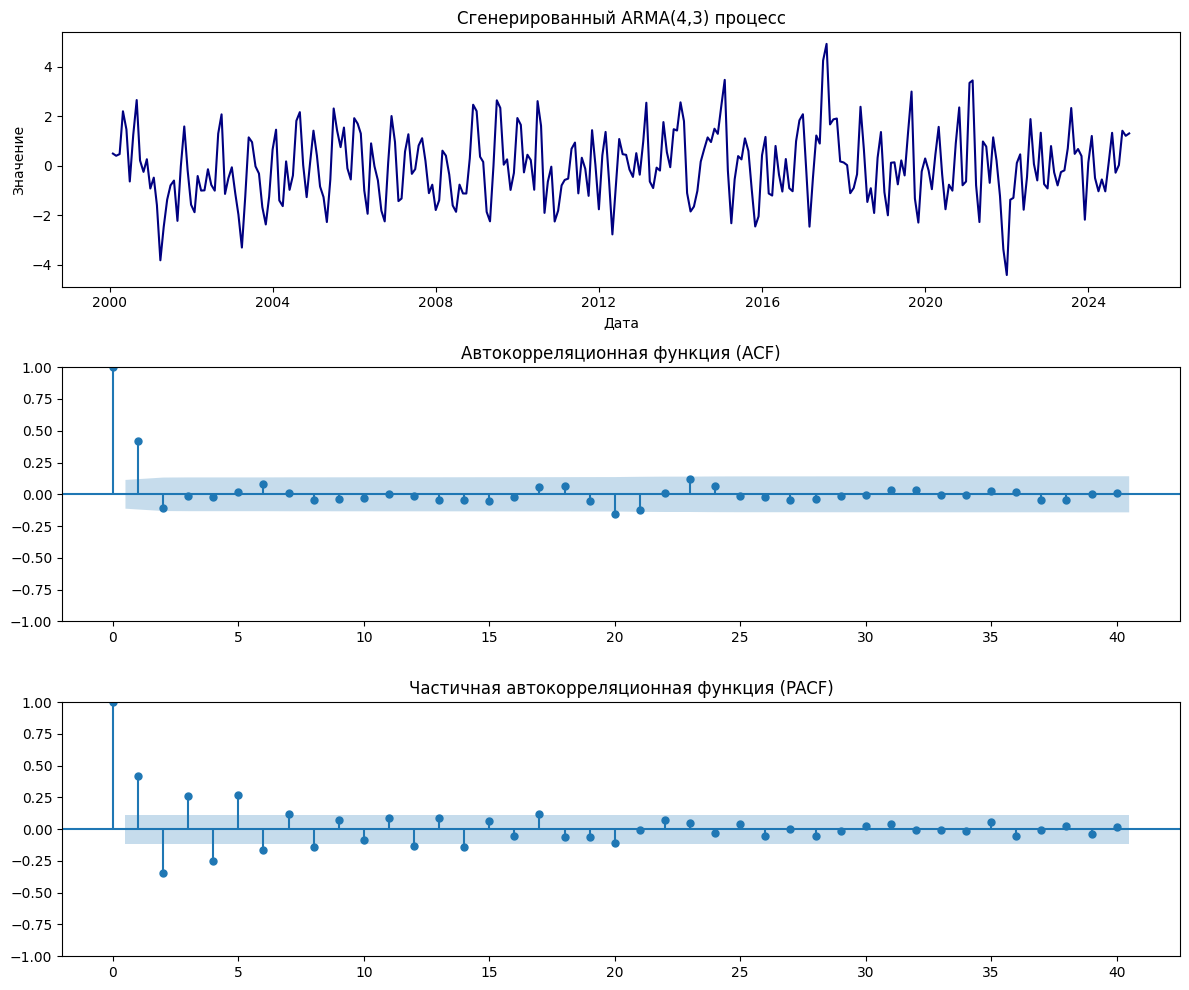

In [23]:
fig, axes = plt.subplots(3, 1, figsize=(12, 10))
axes[0].plot(ts, color='navy')
axes[0].set_title('Сгенерированный ARMA(4,3) процесс')
axes[0].set_xlabel('Дата')
axes[0].set_ylabel('Значение')

plot_acf(ts, lags=40, ax=axes[1], alpha=0.05)
axes[1].set_title('Автокорреляционная функция (ACF)')

plot_pacf(ts, lags=40, ax=axes[2], alpha=0.05)
axes[2].set_title('Частичная автокорреляционная функция (PACF)')

plt.tight_layout()
plt.show()

**Определение параметров p и q по графикам**

- **PACF**: обрывается после лага 4 → p ≈ 4
- **ACF**: обрывается после лага 3 → q ≈ 3

Это соответствует истинной модели ARMA(4,3).

**5. Обучение SARIMAX**

Используем модель SARIMAX с порядком (p, d, q) = (4, 0, 3), без сезонной компоненты.

In [24]:
model = SARIMAX(ts, order=(4, 0, 3), trend='c')   # включаем константу
# Стартовые значения близки к истинным параметрам — помогает сходимости MLE для ARMA(4,3)
start_params = np.r_[0.0, phi, theta, np.var(data, ddof=0)]
results = model.fit(disp=False, maxiter=500, start_params=start_params)

print(results.summary())

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  300
Model:               SARIMAX(4, 0, 3)   Log Likelihood                -418.978
Date:                Fri, 01 May 2026   AIC                            855.957
Time:                        19:47:14   BIC                            889.291
Sample:                    01-31-2000   HQIC                           869.297
                         - 12-31-2024                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept   3.501e-05      0.002      0.017      0.986      -0.004       0.004
ar.L1          0.2497      0.201      1.239      0.215      -0.145       0.645
ar.L2          0.5809      0.194      2.992      0.0

**6. Анализ обученной модели**

Запишем уравнение обученной модели:

$$X_t = \hat{c} + \hat{\phi}_1 X_{t-1} + \hat{\phi}_2 X_{t-2} + \hat{\phi}_3 X_{t-3} + \hat{\phi}_4 X_{t-4} + \varepsilon_t + \hat{\theta}_1 \varepsilon_{t-1} + \hat{\theta}_2 \varepsilon_{t-2} + \hat{\theta}_3 \varepsilon_{t-3}$$

In [25]:
print("\nОценённые коэффициенты:")
print(f"Константа (intercept): {results.params['intercept']:.4f}")
print(f"AR(1): {results.params['ar.L1']:.4f} (истинный φ1 = {phi[0]})")
print(f"AR(2): {results.params['ar.L2']:.4f} (истинный φ2 = {phi[1]})")
print(f"AR(3): {results.params['ar.L3']:.4f} (истинный φ3 = {phi[2]})")
print(f"AR(4): {results.params['ar.L4']:.4f} (истинный φ4 = {phi[3]})")
print(f"MA(1): {results.params['ma.L1']:.4f} (истинный θ1 = {theta[0]})")
print(f"MA(2): {results.params['ma.L2']:.4f} (истинный θ2 = {theta[1]})")
print(f"MA(3): {results.params['ma.L3']:.4f} (истинный θ3 = {theta[2]})")


Оценённые коэффициенты:
Константа (intercept): 0.0000
AR(1): 0.2497 (истинный φ1 = 0.6)
AR(2): 0.5809 (истинный φ2 = -0.4)
AR(3): 0.1378 (истинный φ3 = 0.2)
AR(4): 0.0066 (истинный φ4 = -0.1)
MA(1): 0.7642 (истинный θ1 = 0.5)
MA(2): -0.9927 (истинный θ2 = -0.3)
MA(3): -0.7685 (истинный θ3 = 0.19)


**Выводы:**

- По корням характеристических полиномов (с **правильным** порядком коэффициентов для `numpy.roots`) и по `ArmaProcess.isstationary` / `isinvertible` смоделированный процесс **стационарен и обратим**. Коэффициент θ₃ слегка уменьшен (0.19 вместо 0.20), чтобы у MA-полинома не было корня на единичной окружности.
- Оценки SARIMAX по выборке из 300 наблюдений могут **заметно отличаться** от истинных φ и θ: для ARMA высокого порядка возможны слабая идентифицируемость и несколько близких по правдоподобию решений; тем не менее модель задаёт корректный порядок (4, 3) и подгоняет данные.
- По ACF/PACF выбраны порядки p и q; итоговое уравнение с оценёнными коэффициентами приведено в `summary` и в блоке с численными коэффициентами выше.
- Для прогнозирования имеет смысл смотреть на информационные критерии, диагностику остатков и при необходимости упрощать порядок модели.